In [1]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict,  Literal

In [8]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [23]:
def show_equation(state: QuadState):
    #equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    equation = f'{state["a"]}x²{state["b"]:+0}x{state["c"]:+0}'
    return {'equation': equation}

In [24]:
def calculate_discriminent(state: QuadState):
    discriminant = state['b']**2 - (4*state['a'] * state['c'])
    return {'discriminant': discriminant}

In [25]:
def real_roots(state: QuadState):
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])

    result = f'The roots are {root1} and {root2}'
    return {'result': result}

In [26]:
def repeated_roots(state: QuadState):
    root = (-state['b'] ) / (2*state['a'])
    

    result = f'The only repeating root is {root}'
    return {'result': result}

In [27]:
def no_real_roots(state: QuadState):
    result = f'No real root'
    return {'result': result}

In [28]:
def check_condition(state: QuadState)-> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    if state['discriminant'] > 0: 
        return 'real_roots'
    elif state['discriminant'] ==0:
        return 'repeated_roots'
    else: 
        return 'no_real_roots'

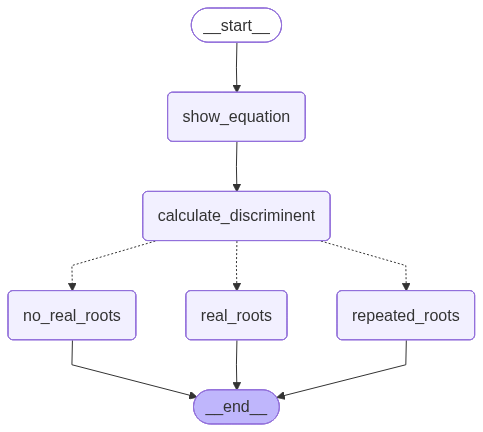

In [29]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminent', calculate_discriminent)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminent')

# conditional edge
graph.add_conditional_edges('calculate_discriminent', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()
workflow

In [32]:
initial_state = {
    'a': 2, 
    'b': 4, 
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x²+4x+2',
 'discriminant': 0,
 'result': 'The only repeating root is -1.0'}